# CH03_06. 컨텍스트 격리: 서브 에이전트 위임

## 1. 환경 설정

In [2]:
import os
from dotenv import load_dotenv
import warnings

load_dotenv()
warnings.filterwarnings("ignore")

# 환경 변수 확인
print("=== LangSmith 설정 상태 ===")
print(f"LANGSMITH_API_KEY: {'설정됨' if os.getenv('LANGSMITH_API_KEY') else '미설정 ⚠️'}")
print(f"LANGSMITH_TRACING: {os.getenv('LANGSMITH_TRACING', '미설정')}")
print(f"LANGSMITH_PROJECT: {os.getenv('LANGSMITH_PROJECT', '미설정 (default 사용)')}")
print(f"OPENAI_API_KEY: {'설정됨' if os.getenv('OPENAI_API_KEY') else '미설정 ⚠️'}")

# 프로젝트 이름 설정 (선택)
os.environ["LANGSMITH_PROJECT"] = "fc-agent-bible-appendix"
print("fc-agent-bible-appendix 프로젝트의 Tracing이 활성화되었습니다.")

=== LangSmith 설정 상태 ===
LANGSMITH_API_KEY: 설정됨
LANGSMITH_TRACING: 미설정
LANGSMITH_PROJECT: fc-agent-bible-appendix
OPENAI_API_KEY: 설정됨
fc-agent-bible-appendix 프로젝트의 Tracing이 활성화되었습니다.


In [3]:
from pathlib import Path
from datetime import datetime
from exa_py import Exa

# EXA API 클라이언트 초기화
exa_client = Exa(api_key=os.environ["EXA_API_KEY"])

# 워크스페이스 디렉토리 (서브 에이전트가 파일 저장 시 사용)
WORKSPACE_DIR = Path("./agent_workspace")
WORKSPACE_DIR.mkdir(exist_ok=True)

def get_today_str() -> str:
    return datetime.now().strftime("%Y-%m-%d")

# utils.py가 있는 경로 추가
import sys
sys.path.append(".")

from utils import format_messages, show_prompt

print(f"✅ 환경 설정 완료")
print(f"📁 워크스페이스: {WORKSPACE_DIR.absolute()}")
print(f"🔍 EXA API 클라이언트 초기화 완료")

✅ 환경 설정 완료
📁 워크스페이스: c:\Users\shdnc\OneDrive\Desktop\UNIST\2026 생운관\File_maker_Project\agent_workspace
🔍 EXA API 클라이언트 초기화 완료


## 2. 상태 및 기본 도구 정의

In [4]:
from typing_extensions import TypedDict, Annotated, Optional, NotRequired
from langgraph.graph.message import add_messages
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool, InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langgraph.types import Command

# 파일 리듀서
def file_reducer(left, right):
    if left is None:
        return right or {}
    if right is None:
        return left
    return {**left, **right}

# Todo 정의
class Todo(TypedDict):
    content: str
    status: str

# 에이전트 상태 정의
class DeepAgentState(TypedDict):
    messages: Annotated[list, add_messages]
    todos: NotRequired[list[Todo]]
    files: Annotated[NotRequired[dict[str, str]], file_reducer]

# 파일 도구들
@tool
def ls(state: Annotated[DeepAgentState, InjectedState]) -> list[str]:
    """가상 파일 시스템의 모든 파일을 나열합니다."""
    files = state.get("files", {})
    return list(files.keys()) if files else ["(파일이 없습니다)"]

@tool
def read_file(
    file_path: str,
    state: Annotated[DeepAgentState, InjectedState],
) -> str:
    """파일 내용을 읽습니다."""
    files = state.get("files", {})
    if file_path not in files:
        return f"오류: 파일 '{file_path}'을(를) 찾을 수 없습니다."
    return files[file_path]

@tool
def write_file(
    file_path: str,
    content: str,
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """파일에 내용을 작성합니다."""
    return Command(
        update={
            "files": {file_path: content},
            "messages": [
                ToolMessage(f"파일 '{file_path}'이(가) 저장되었습니다.", tool_call_id=tool_call_id)
            ],
        }
    )

print("✅ 기본 상태 및 도구가 정의되었습니다.")

✅ 기본 상태 및 도구가 정의되었습니다.


## 3. 서브 에이전트 정의

In [5]:
from typing_extensions import TypedDict
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain_core.tools import BaseTool

class SubAgent(TypedDict):
    """서브 에이전트 설정"""
    name: str           # 에이전트 식별자
    description: str    # 에이전트 기능 설명 (감독자용)
    prompt: str         # 시스템 프롬프트
    tools: NotRequired[list[str]]  # 사용할 도구 목록 (선택)

# EXA 기반 웹 검색 도구 (서브 에이전트용 - 컨텍스트 오프로딩 포함)
@tool(parse_docstring=True)
def web_search(query: str) -> str:
    """Search the web for information using EXA and save results to a file.
    
    This tool performs semantic web search using EXA API. Full results are
    saved to a local file for context offloading, and a concise summary is returned.

    Args:
        query: The search query - be specific and clear about what you're looking for

    Returns:
        A summary of search results with the filename where full content is saved
    
    Example:
        web_search("LangGraph multi-agent architecture patterns")
    """
    try:
        # EXA 검색 수행
        results = exa_client.search_and_contents(
            query=query,
            num_results=5,
            text={"max_characters": 2000},
            highlights={"num_sentences": 3}
        )
        
        # 파일에 저장할 상세 내용
        file_content = f"# Search Results: {query}\n"
        file_content += f"**Date:** {get_today_str()}\n\n---\n\n"
        
        for i, result in enumerate(results.results, 1):
            file_content += f"## {i}. {result.title}\n"
            file_content += f"**URL:** {result.url}\n\n"
            
            if result.highlights:
                file_content += "### Highlights:\n"
                for highlight in result.highlights:
                    file_content += f"- {highlight}\n"
            
            if result.text:
                file_content += f"\n### Content:\n{result.text}\n"
            
            file_content += "\n---\n\n"
        
        # 파일 저장
        safe_query = query.lower().replace(" ", "_")[:30]
        filename = f"search_{safe_query}_{get_today_str()}.md"
        target_file = WORKSPACE_DIR / filename
        target_file.write_text(file_content, encoding="utf-8")
        
        # 요약 반환
        summary = f"🔍 Search: \"{query}\"\n📄 Saved to: {filename}\n\n**Key findings:**\n"
        for i, result in enumerate(results.results[:3], 1):
            summary += f"{i}. {result.title}\n"
            if result.highlights:
                summary += f"   → {result.highlights[0][:150]}...\n"
        
        return summary
        
    except Exception as e:
        return f"Search error: {str(e)}"

print("✅ 서브 에이전트 타입 및 EXA 검색 도구 정의 완료")

✅ 서브 에이전트 타입 및 EXA 검색 도구 정의 완료


## 4. task 도구 생성 함수

In [6]:
# task 도구 설명 템플릿
TASK_DESCRIPTION_PREFIX = """
특화된 서브 에이전트에게 작업을 위임합니다.

각 서브 에이전트는 격리된 컨텍스트에서 실행되어 컨텍스트 충돌을 방지합니다.
서브 에이전트는 부모의 대화 기록을 볼 수 없으므로, 완전한 독립 지시를 제공하세요.

## 사용 가능한 서브 에이전트:
{other_agents}

## 파라미터:
- description: 서브 에이전트에게 전달할 명확하고 구체적인 작업 지시
- subagent_type: 사용할 서브 에이전트 이름
"""

def create_task_tool(tools, subagents: list[SubAgent], model, state_schema):
    """서브 에이전트 위임을 위한 task 도구를 생성합니다.
    
    Args:
        tools: 서브 에이전트가 사용할 수 있는 도구 목록
        subagents: 서브 에이전트 설정 목록
        model: 사용할 언어 모델
        state_schema: 상태 스키마
    
    Returns:
        task 도구
    """
    # 에이전트 레지스트리 생성
    agents = {}
    
    # 도구 이름으로 매핑
    tools_by_name = {}
    for tool_ in tools:
        if not isinstance(tool_, BaseTool):
            tool_ = tool(tool_)
        tools_by_name[tool_.name] = tool_
    
    # 서브 에이전트 생성
    for _agent in subagents:
        if "tools" in _agent:
            _tools = [tools_by_name[t] for t in _agent["tools"]]
        else:
            _tools = tools
        
        agents[_agent["name"]] = create_agent(
            model,
            tools=_tools,
            system_prompt=_agent["prompt"],
            state_schema=state_schema,
        )
    
    # 서브 에이전트 설명 문자열 생성
    other_agents_string = "\n".join([
        f"- **{_agent['name']}**: {_agent['description']}" for _agent in subagents
    ])
    
    @tool(description=TASK_DESCRIPTION_PREFIX.format(other_agents=other_agents_string))
    def task(
        description: str,
        subagent_type: str,
        state: Annotated[DeepAgentState, InjectedState],
        tool_call_id: Annotated[str, InjectedToolCallId],
    ):
        """특화된 서브 에이전트에게 작업을 위임합니다."""
        # 1. 서브 에이전트 타입 검증
        if subagent_type not in agents:
            return f"오류: '{subagent_type}'은(는) 존재하지 않습니다. 사용 가능: {list(agents.keys())}"
        
        # 2. 서브 에이전트 가져오기
        sub_agent = agents[subagent_type]
        
        # 3. 격리된 컨텍스트 생성 (핵심!)
        # 부모의 대화 기록을 전달하지 않고, 오직 작업 설명만 전달
        isolated_state = dict(state)  # 상태 복사
        isolated_state["messages"] = [{"role": "user", "content": description}]
        
        # 4. 서브 에이전트 실행
        result = sub_agent.invoke(isolated_state)
        
        # 5. 결과를 부모 에이전트에 반환
        return Command(
            update={
                "files": result.get("files", {}),  # 파일 변경 사항 병합
                "messages": [
                    ToolMessage(
                        result["messages"][-1].content,
                        tool_call_id=tool_call_id
                    )
                ],
            }
        )
    
    return task

print("✅ task 도구 생성 함수 정의 완료")

✅ task 도구 생성 함수 정의 완료


## 5. 리서치 서브 에이전트 정의

In [7]:
# 리서치 서브 에이전트 프롬프트 (레퍼런스: RESEARCHER_INSTRUCTIONS)
SIMPLE_RESEARCH_INSTRUCTIONS = """당신은 사용자의 입력 주제에 대해 리서치를 수행하는 리서치 어시스턴트입니다. 참고로, 오늘 날짜는 {date}입니다.

<Task>
당신의 임무는 도구를 활용해 사용자의 입력 주제에 관한 정보를 수집하는 것입니다.
제공된 도구를 사용하여 리서치 질문에 답변하는 데 도움이 될 자료를 찾아내세요.
</Task>

<사용 가능한 도구>
1. **web_search**: 정보를 수집하기 위한 웹 검색
   - 검색 결과는 자동으로 파일로 저장되어 컨텍스트 오프로딩에 활용됩니다.
   - 요약 결과가 함께 제공됩니다.

**중요: 반드시 한 번의 집중된 web_search 호출만 진행하고, 그 결과로 답변하세요**
</사용 가능한 도구>

<지침>
시간이 제한된 인간 리서처처럼 사고하세요:
1. **질문을 주의 깊게 읽으세요** - 사용자가 필요한 구체적 정보는 무엇인가요?
2. **한 번의 집중된 검색을 하세요** - 구체적이고 포괄적인 검색어를 작성하세요.
3. **검색 결과를 활용하세요** - 찾은 정보에 근거하여 답변하세요.
</지침>

<하드 리밋>
- 어떤 쿼리에도 **최대 1~2회 검색**만 허용됩니다.
- 답변에 충분한 정보가 확보되면 **즉시 멈추세요**
- 과도한 검색을 금지합니다 - 현재까지 찾은 내용만으로 답변을 작성하세요
</하드 리밋>
""".format(date=get_today_str())

# 리서치 서브 에이전트 설정
research_sub_agent = {
    "name": "research-agent",
    "description": "리서치 업무를 서브에이전트에게 위임합니다. 반드시 하나의 주제만 이 리서처에게 전달하세요.",
    "prompt": SIMPLE_RESEARCH_INSTRUCTIONS,
    "tools": ["web_search"],
}

print("✅ 리서치 서브 에이전트 정의 완료")
print(f"   - 이름: {research_sub_agent['name']}")
print(f"   - 도구: {research_sub_agent['tools']}")

# 프롬프트 확인
show_prompt(SIMPLE_RESEARCH_INSTRUCTIONS)

✅ 리서치 서브 에이전트 정의 완료
   - 이름: research-agent
   - 도구: ['web_search']


╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  당신은 사용자의 입력 주제에 대해 리서치를 수행하는 리서치 어시스턴트입니다. 참고로, 오늘 날짜는                │
│  2026-05-05입니다.                                                                                              │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  당신의 임무는 도구를 활용해 사용자의 입력 주제에 관한 정보를 수집하는 것입니다.                                │
│  제공된 도구를 사용하여 리서치 질문에 답변하는 데 도움이 될 자료를 찾아내세요.                                  │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <사용 가능한 도구>                                                                                             │
│  1. **web_search**: 정보를 수집하기 위한 웹 검색                                                                │
│     - 검색 결과는 자동으로 파일로 저장되어 컨텍스트 오프로딩에 활용됩니다.                                      │
│     - 요약 결과가 함께 제공됩니다.                                                                              │
│                                                                                                                 │
│  **중요: 반드시 한 번의 집중된 web_search 호출만 진행하고, 그 결과로 답변하세요**                               │
│  </사용 가능한 도구>                                                                                            │
│                                                                                                                 │
│  <지침>                                                                                                         │
│  시간이 제한된 인간 리서처처럼 사고하세요:                                                                      │
│  1. **질문을 주의 깊게 읽으세요** - 사용자가 필요한 구체적 정보는 무엇인가요?                                   │
│  2. **한 번의 집중된 검색을 하세요** - 구체적이고 포괄적인 검색어를 작성하세요.                                 │
│  3. **검색 결과를 활용하세요** - 찾은 정보에 근거하여 답변하세요.                                               │
│  </지침>                                                                                                        │
│                                                                                                                 │
│  <하드 리밋>                                                                                                    │
│  - 어떤 쿼리에도 **최대 1~2회 검색**만 허용됩니다.                                                              │
│  - 답변에 충분한 정보가 확보되면 **즉시 멈추세요**                                                              │
│  - 과도한 검색을 금지합니다 - 현재까지 찾은 내용만으로 답변을 작성하세요                                        │
│  </하드 리밋>                                                                                                   │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## 6. 감독자 에이전트 생성

감독자 에이전트는 서브 에이전트에게 작업을 위임합니다.

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  당신은 작업을 서브에이전트에게 위임할 수 있습니다. 오늘 날짜는 2026-05-05입니다.                               │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  당신의 역할은 서브에이전트에게 구체적인 리서치 작업을 위임하여 리서치 과정을 조율하는 것입니다.                │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <사용 가능한 도구>                                                                                             │
│  1. **task(설명, 서브에이전트_종류)**: 전문 서브에이전트에게 리서치 작업을 위임합니다                           │
│     - 설명: 명확하고 구체적인 리서치 질문 또는 작업                                                             │
│     - 서브에이전트_종류: 사용할 에이전트 유형 (예: "research-agent")                                            │
│                                                                                                                 │
│  **병렬 리서치**: 서로 독립적인 리서치 주제가 여러 개라면, 한 번의 응답 내에서 **task** 도구를 여러 번          │
│  호출하세요. 한 번에 최대 3개의 서브에이전트만 병렬로 사용할 수 있습니다.                                       │
│  </사용 가능한 도구>                                                                                            │
│                                                                                                                 │
│  <하드 리밋>                                                                                                    │
│  **작업 위임 한도** (과도한 위임 방지):                                                                         │
│  - **집중 리서치 우선**: 단순 질문에는 하나의 에이전트만 사용하고, 정말 필요할 때만 여러 명을 사용하세요        │
│  - **충분할 때 멈추세요**: 정보를 충분히 얻었다면 추가 리서치를 멈추세요                                        │
│  - **반복 제한**: 3회 이상 task 도구 호출(반복) 하지 마세요. 그 이상 이후에도 충분한 소스를 얻지 못했다면       │
│  중단해야 합니다.                                                                                               │
│  </하드 리밋>                                                                                                   │
│                                                                                                                 │
│  <세부 지침>                                                                                                    │
│  **단순 정보 탐색, 목록, 랭킹** 등은 1명의 서브에이전트로 충분합니다:                                           │
│  - *예시*: "Model Context Protocol이 무엇인가요?" → 1명 사용                                                    │
│                                                                                                                 │
│  **비교가 필요한 경우**는 비교할 요소마다 별도의 서브에이전트를 사용하세요:                                     │
│  - *예시*: "LangChain과 LangGraph 비교해줘" → 2명 사용(각각 담당)                                               │
│                                                                                                                 │
│  **다각적 리서치**는 각 측면별로 병렬 서브에이전트를 쓸 수 있습니다:                                            │
│  - *예시*: "AI 에이전트의 아키텍처, 도구, 사용사례 리서치" → 3명 사용                                           │
│                                                                                                                 │
│  **중요 사항:**                                                                                                 │
│  - 각 **task** 호출마다 자체 컨텍스트를 가진 독립된 리서치 에이전트를 생성합니다.                               │
│  - 서브에이전트끼리는 서로의 작업 결과를 볼 수 없습니다 — 각각 완전히 독립적인 지침을 주세요.                   │
│  - task 설명에는 약어, 두문자어 사용을 피하고 명확하고 구체적인 문장을 사용하세요.                              │
│  </세부 지침>                                                           


✅ 감독자 에이전트가 생성되었습니다.

📊 에이전트 그래프 구조:


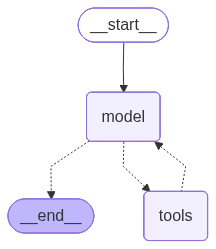

In [8]:
from datetime import datetime
from IPython.display import Image, display

# 병렬 처리 제한
max_concurrent_research_units = 3
max_researcher_iterations = 3

# 감독자 에이전트 프롬프트 (한글화 버전)
SUPERVISOR_INSTRUCTIONS = """당신은 작업을 서브에이전트에게 위임할 수 있습니다. 오늘 날짜는 {date}입니다.

<Task>
당신의 역할은 서브에이전트에게 구체적인 리서치 작업을 위임하여 리서치 과정을 조율하는 것입니다.
</Task>

<사용 가능한 도구>
1. **task(설명, 서브에이전트_종류)**: 전문 서브에이전트에게 리서치 작업을 위임합니다
   - 설명: 명확하고 구체적인 리서치 질문 또는 작업
   - 서브에이전트_종류: 사용할 에이전트 유형 (예: "research-agent")

**병렬 리서치**: 서로 독립적인 리서치 주제가 여러 개라면, 한 번의 응답 내에서 **task** 도구를 여러 번 호출하세요. 한 번에 최대 {max_concurrent}개의 서브에이전트만 병렬로 사용할 수 있습니다.
</사용 가능한 도구>

<하드 리밋>
**작업 위임 한도** (과도한 위임 방지):
- **집중 리서치 우선**: 단순 질문에는 하나의 에이전트만 사용하고, 정말 필요할 때만 여러 명을 사용하세요
- **충분할 때 멈추세요**: 정보를 충분히 얻었다면 추가 리서치를 멈추세요
- **반복 제한**: {max_iterations}회 이상 task 도구 호출(반복) 하지 마세요. 그 이상 이후에도 충분한 소스를 얻지 못했다면 중단해야 합니다.
</하드 리밋>

<세부 지침>
**단순 정보 탐색, 목록, 랭킹** 등은 1명의 서브에이전트로 충분합니다:
- *예시*: "Model Context Protocol이 무엇인가요?" → 1명 사용

**비교가 필요한 경우**는 비교할 요소마다 별도의 서브에이전트를 사용하세요:
- *예시*: "LangChain과 LangGraph 비교해줘" → 2명 사용(각각 담당)

**다각적 리서치**는 각 측면별로 병렬 서브에이전트를 쓸 수 있습니다:
- *예시*: "AI 에이전트의 아키텍처, 도구, 사용사례 리서치" → 3명 사용

**중요 사항:**
- 각 **task** 호출마다 자체 컨텍스트를 가진 독립된 리서치 에이전트를 생성합니다.
- 서브에이전트끼리는 서로의 작업 결과를 볼 수 없습니다 — 각각 완전히 독립적인 지침을 주세요.
- task 설명에는 약어, 두문자어 사용을 피하고 명확하고 구체적인 문장을 사용하세요.
</세부 지침>
""".format(date=get_today_str(), max_concurrent=max_concurrent_research_units, max_iterations=max_researcher_iterations)

# 프롬프트 확인
show_prompt(SUPERVISOR_INSTRUCTIONS)

# 모델 초기화
model = init_chat_model(model="openai:gpt-4o-mini", temperature=0.0)

# 서브 에이전트용 도구 (web_search만)
sub_agent_tools = [web_search]

# task 도구 생성
task_tool = create_task_tool(
    tools=sub_agent_tools,
    subagents=[research_sub_agent],
    model=model,
    state_schema=DeepAgentState,
)

# 감독자 에이전트 도구
supervisor_tools = [task_tool]

# 감독자 에이전트 생성
supervisor_agent = create_agent(
    model,
    tools=supervisor_tools,
    system_prompt=SUPERVISOR_INSTRUCTIONS,
    state_schema=DeepAgentState,
)

print("\n✅ 감독자 에이전트가 생성되었습니다.")
print("\n📊 에이전트 그래프 구조:")
display(Image(supervisor_agent.get_graph(xray=True).draw_mermaid_png()))

## 7. 에이전트 실행

감독자 에이전트에게 여러 주제에 대한 리서치를 요청합니다.

In [10]:
# 에이전트 실행 (스트리밍 모드)
print("🚀 감독자 에이전트 실행 시작 (스트리밍)")
print("=" * 60)

query = {
    "messages": [
        {
            "role": "user",
            "content": "EOQ (Economic Order Quantity)이랑 JIT (Just-In-Time)을 비교해줘",
        }
    ],
}

# 스트리밍으로 실행 과정 확인 (서브그래프 포함)
for namespace, mode, chunk in supervisor_agent.stream(
    query, 
    stream_mode=["updates", "values"], 
    subgraphs=True
):
    if mode == "updates":
        # 현재 그래프 이름 표시
        graph_name = namespace if len(namespace) > 0 else "main"
        
        for node_name, value in chunk.items():
            print(f"\n📍 [{graph_name}] → [{node_name}]")
            
            if "messages" in value and value["messages"]:
                last_msg = value["messages"][-1]
                
                # Tool Call 표시
                if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                    for tc in last_msg.tool_calls:
                        print(f"   🔧 Tool: {tc['name']}")
                        if tc.get('args'):
                            args_str = str(tc['args'])[:80]
                            print(f"   📝 Args: {args_str}...")
                
                # 응답 표시
                elif hasattr(last_msg, 'content') and last_msg.content:
                    content = str(last_msg.content)[:300]
                    print(f"   💬 {content}...")

print("\n" + "=" * 60)
print("✅ 실행 완료")

🚀 감독자 에이전트 실행 시작 (스트리밍)

📍 [main] → [model]
   🔧 Tool: task
   📝 Args: {'description': 'Economic Order Quantity의 정의, 장점, 단점에 대해 설명해줘.', 'subagent_type'...
   🔧 Tool: task
   📝 Args: {'description': 'Just-In-Time의 정의, 장점, 단점에 대해 설명해줘.', 'subagent_type': 'research...

📍 [main] → [tools]
   💬 **Just-In-Time (JIT) 정의, 장점, 단점**

### 정의
Just-In-Time (JIT) 시스템은 필요할 때, 필요한 만큼만 제품을 생산하는 생산 방식입니다. 이 개념은 1970년대 일본의 도요타에서 처음 개발되었으며, 생산 과정에서 불필요한 재고를 없애고 자원의 낭비를 최소화하는 데 중점을 둡니다. JIT는 수요 중심적이며, 생산 일정과 자재 공급을 고객의 수요에 맞춰 조정합니다.

### 장점
1. **재고 비용 절감**: JIT는 재고를 최소화하여 보관 비용과 재고 관리 비용을 줄입니다.
2. **효율성 향...

📍 [main] → [tools]
   💬 **Economic Order Quantity (EOQ)**는 재고 관리에서 사용되는 모델로, 총 재고 비용을 최소화하는 주문량을 결정하는 데 도움을 줍니다. EOQ는 주문 비용과 재고 유지 비용 간의 균형을 맞추어 최적의 주문량을 계산합니다.

### 정의
EOQ는 재고를 보유하고 있는 기업이 주문할 최적의 수량을 결정하는 방법으로, 다음과 같은 공식으로 계산됩니다:

\[
EOQ = \sqrt{\frac{2DS}{H}}
\]

- \(D\): 연간 수요량
- \(S\): 주문당 비용
- \(H\): 단위당 연간 보관 비용

##...

📍 [main] → [model]
   💬 ### Economic Order Quantity (EOQ)

**정의**  
Economi